<a href="https://colab.research.google.com/github/GIRIAYUSH/playing-with-anns/blob/main/notebooks/M4_BackPropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing all necessary libraries

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from typing import Dict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
torch.manual_seed(42) #for reproducability
np.random.seed(42)

"""
## Mathematical Foundation: Chain Rule & Backpropagation

For a neural network with layers: **x → z¹ → a¹ → z² → a² → ... → zᴸ → ŷ**

Where for layer l:
- **zˡ = Wˡ aˡ⁻¹ + bˡ** (pre-activation)
- **aˡ = σ(zˡ)** (activation)

### The Chain Rule
If y = f(g(x)), then: **dy/dx = (dy/dg) · (dg/dx)**

### Backpropagation Equations (Layer l):

**1. Output Gradient (Error Signal):**
δᴸ = ∂L/∂zᴸ = (∂L/∂ŷ) ⊙ σ'(zᴸ)

**2. Hidden Layer Gradient:**
δˡ = (Wˡ⁺¹ᵀ δˡ⁺¹) ⊙ σ'(zˡ)

**3. Weight Gradients:**
∂L/∂Wˡ = δˡ · aˡ⁻¹ᵀ

**4. Bias Gradients:**
∂L/∂bˡ = δˡ

### For Binary Classification (Sigmoid + BCE):
Loss: L = -[y·log(ŷ) + (1-y)·log(1-ŷ)]

∂L/∂ŷ = -y/ŷ + (1-y)/(1-ŷ)

Since ŷ = σ(z) and σ'(z) = σ(z)(1-σ(z)) = ŷ(1-ŷ):

**δᴸ = ∂L/∂zᴸ = ŷ - y**  (Beautiful simplification!)

### For Multi-class (Softmax + Cross-Entropy):
Loss: L = -Σ yᵢ log(ŷᵢ)

With ŷ = softmax(z):

**δᴸ = ŷ - y**

### Setting Up a Forward Pass and Backprop from Scratch

In [23]:
class BinaryClassifierManual(nn.Module):
    """
    2-Layer Binary Classifier with Manual Backpropagation

    Architecture: Input → Linear → ReLU → Dropout → Linear → Sigmoid

    Forward:
        z₁ = W₁·x + b₁          (batch, hidden_dim)
        a₁ = ReLU(z₁)            (batch, hidden_dim)
        a₁_dropped = Dropout(a₁) (batch, hidden_dim)
        z₂ = W₂·a₁_dropped + b₂  (batch, 1)
        ŷ = σ(z₂)                (batch, 1)
    """

    def __init__(self, input_dim: int, hidden_dim: int, dropout_p: float = 0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim, bias=True)
        self.dropout1 = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_dim, 1, bias=True)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self._cache = {}

    def forward(self, x: torch.Tensor, store_cache: bool = True) -> torch.Tensor:
        z1 = self.fc1(x)
        a1 = self.relu(z1)
        a1_dropped = self.dropout1(a1)
        z2 = self.fc2(a1_dropped)
        out = self.sigmoid(z2)

        if store_cache:
            self._cache = {
                'x': x.detach().clone(),
                'z1': z1.detach().clone(),
                'a1': a1.detach().clone(),
                'a1_dropped': a1_dropped.detach().clone(),
                'z2': z2.detach().clone(),
                'out': out.detach().clone(),
            }
        return out

    def manual_backward(self, y_true: torch.Tensor, loss_fn) -> Dict[str, torch.Tensor]:
        """
        Manual backpropagation using the chain rule.

        For BCE + Sigmoid: δ₂ = ŷ - y
        Derivation:
            L = -[y·log(σ(z)) + (1-y)·log(1-σ(z))]
            ∂L/∂z = -[y·(1-σ(z)) - (1-y)·σ(z)] = σ(z) - y = ŷ - y
        """
        cache = self._cache
        batch_size = y_true.shape[0]

        x = cache['x']
        z1 = cache['z1']
        a1 = cache['a1']
        a1_dropped = cache['a1_dropped']
        out = cache['out']

        W1 = self.fc1.weight      # (hidden_dim, input_dim)
        W2 = self.fc2.weight      # (1, hidden_dim)

        # STEP 1: Output error signal
        delta2 = (out - y_true) / batch_size  # (batch, 1)

        # STEP 2: Output layer gradients
        grad_W2 = delta2.T @ a1_dropped       # (1, hidden_dim)
        grad_b2 = delta2.sum(dim=0)           # (1,)

        # STEP 3: Backprop to hidden layer
        grad_a1 = delta2 @ W2                 # (batch, hidden_dim)
        relu_mask = (z1 > 0).float()          # ReLU derivative
        delta1 = grad_a1 * relu_mask          # (batch, hidden_dim)

        # STEP 4: Hidden layer gradients
        grad_W1 = delta1.T @ x                # (hidden_dim, input_dim)
        grad_b1 = delta1.sum(dim=0)           # (hidden_dim,)

        return {
            'fc1.weight': grad_W1,
            'fc1.bias': grad_b1,
            'fc2.weight': grad_W2,
            'fc2.bias': grad_b2,
            'delta1': delta1,
            'delta2': delta2,
            'relu_mask': relu_mask,
        }

### Testing with Binary Classifier

In [31]:
INPUT_DIM = 10
HIDDEN_DIM = 8
BATCH_SIZE = 4
DROPOUT_P = 0.3

torch.manual_seed(42)
x = torch.randn(BATCH_SIZE, INPUT_DIM)
y = torch.randint(0, 2, (BATCH_SIZE, 1)).float()

model_binary = BinaryClassifierManual(INPUT_DIM, HIDDEN_DIM, DROPOUT_P)
model_binary.eval()

output = model_binary(x, store_cache=True)
loss_fn = nn.BCELoss()
loss = loss_fn(output, y)

# PYTORCH AUTOGRAD
model_binary.zero_grad() # rests gradient
loss.backward(retain_graph=True)
pytorch_grads = {
    'fc1.weight': model_binary.fc1.weight.grad.clone(),
    'fc1.bias': model_binary.fc1.bias.grad.clone(),
    'fc2.weight': model_binary.fc2.weight.grad.clone(),
    'fc2.bias': model_binary.fc2.bias.grad.clone()
}

# MANUAL BACKPROP
manual_grads = model_binary.manual_backward(y, loss_fn)

# VERIFICATION
print("GRADIENT VERIFICATION: Manual vs PyTorch Autograd")
for name in ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']:
    diff = torch.abs(manual_grads[name] - pytorch_grads[name]).max().item()
    print(f"{name}: max_diff={diff:.2e} {'✅ MATCH' if diff < 1e-5 else '❌'}")

GRADIENT VERIFICATION: Manual vs PyTorch Autograd
fc1.weight: max_diff=2.24e-08 ✅ MATCH
fc1.bias: max_diff=7.45e-09 ✅ MATCH
fc2.weight: max_diff=2.98e-08 ✅ MATCH
fc2.bias: max_diff=0.00e+00 ✅ MATCH


### Binary Gradients HeatMap

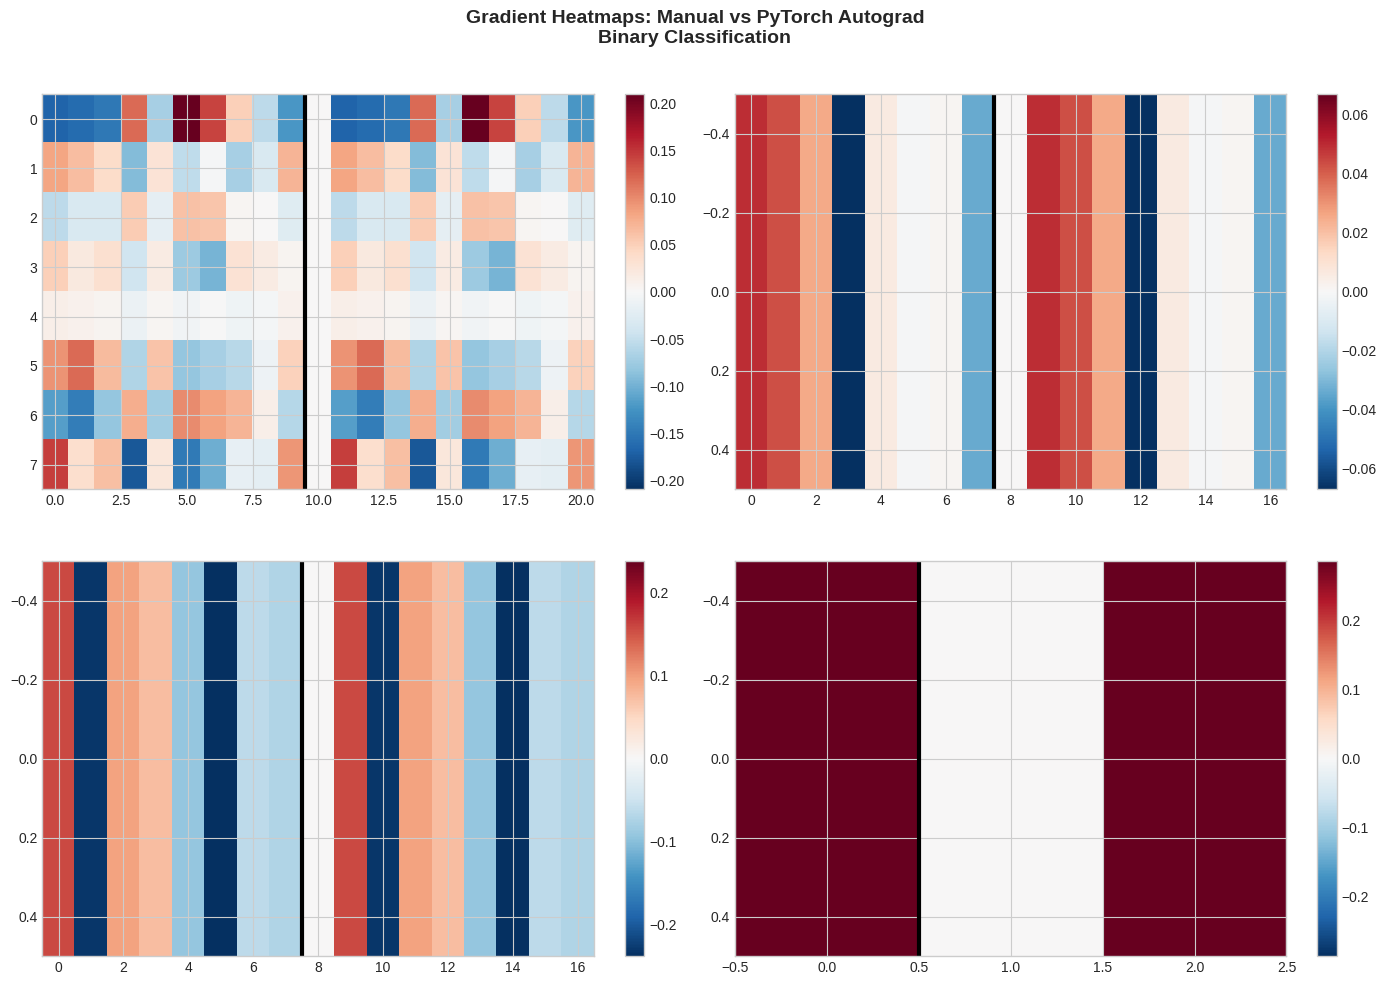

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gradient Heatmaps: Manual vs PyTorch Autograd\nBinary Classification',
             fontsize=14, fontweight='bold')

params = ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']
titles = ['Layer 1 Weights (8×10)', 'Layer 1 Bias (8)', 'Layer 2 Weights (1×8)', 'Layer 2 Bias (1)']

for idx, (param, title) in enumerate(zip(params, titles)):
    ax = axes[idx // 2, idx % 2]
    manual = manual_grads[param].detach().numpy()
    pytorch = pytorch_grads[param].detach().numpy()

    if manual.ndim == 1:
        manual = manual.reshape(1, -1)
        pytorch = pytorch.reshape(1, -1)

    data = np.hstack([manual, np.zeros((manual.shape[0], 1)), pytorch])
    vmax = max(abs(data).max(), 1e-6)
    im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{title}\nLeft: Manual | Right: PyTorch', fontweight='bold')
    ax.axvline(x=manual.shape[1] - 0.5, color='black', linewidth=3)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('binary_grad_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

### Gradient Flow Diagram BackProp through layers

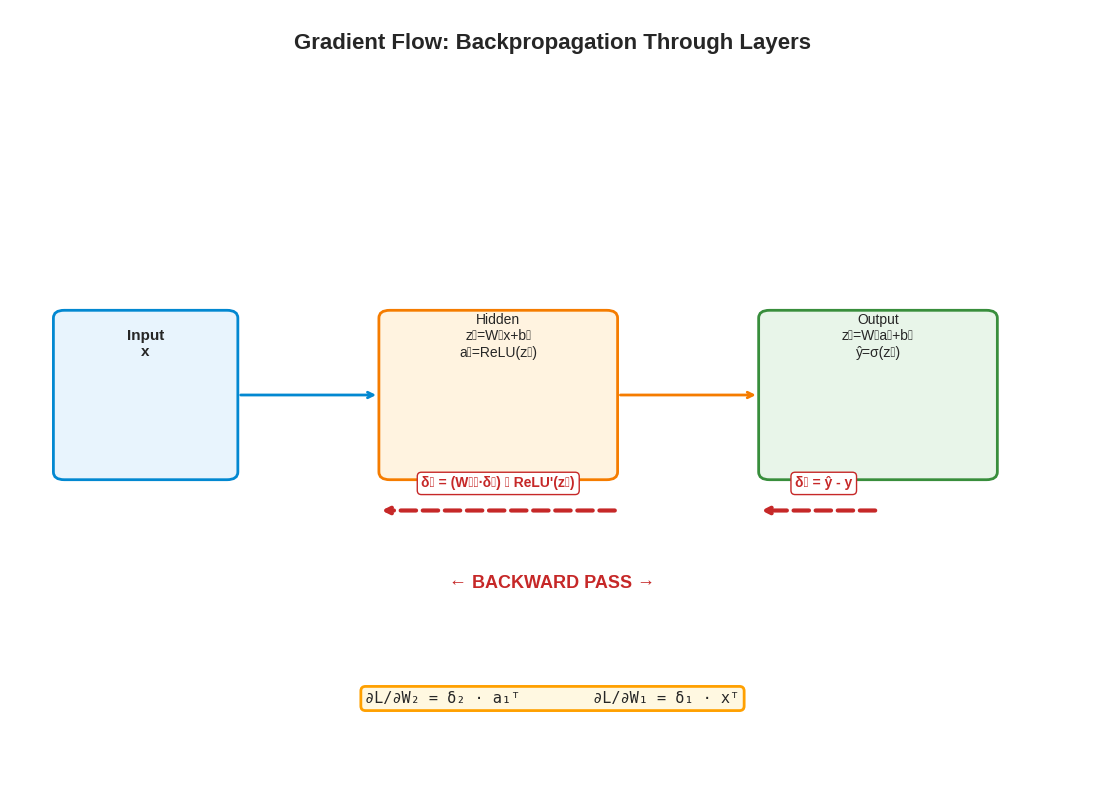

In [29]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

ax.text(5, 9.5, 'Gradient Flow: Backpropagation Through Layers',
        ha='center', fontsize=16, fontweight='bold')

# Layer boxes
input_box = FancyBboxPatch((0.5, 4), 1.5, 2, boxstyle="round,pad=0.1",
                           facecolor='#E8F4FD', edgecolor='#0288D1', linewidth=2)
ax.add_patch(input_box)
ax.text(1.25, 5.5, 'Input\nx', ha='center', fontsize=11, fontweight='bold')

hidden_box = FancyBboxPatch((3.5, 4), 2, 2, boxstyle="round,pad=0.1",
                            facecolor='#FFF3E0', edgecolor='#F57C00', linewidth=2)
ax.add_patch(hidden_box)
ax.text(4.5, 5.5, 'Hidden\nz₁=W₁x+b₁\na₁=ReLU(z₁)', ha='center', fontsize=10)

output_box = FancyBboxPatch((7, 4), 2, 2, boxstyle="round,pad=0.1",
                            facecolor='#E8F5E9', edgecolor='#388E3C', linewidth=2)
ax.add_patch(output_box)
ax.text(8, 5.5, 'Output\nz₂=W₂a₁+b₂\nŷ=σ(z₂)', ha='center', fontsize=10)

# Forward arrows
ax.annotate('', xy=(3.4, 5), xytext=(2.1, 5), arrowprops=dict(arrowstyle='->', color='#0288D1', lw=2))
ax.annotate('', xy=(6.9, 5), xytext=(5.6, 5), arrowprops=dict(arrowstyle='->', color='#F57C00', lw=2))

# Backward error signals (red dashed)
ax.text(5, 2.5, '← BACKWARD PASS →', ha='center', fontsize=13, fontweight='bold', color='#C62828')
ax.annotate('', xy=(6.9, 3.5), xytext=(8, 3.5), arrowprops=dict(arrowstyle='->', color='#C62828', lw=3, ls='--'))
ax.text(7.5, 3.8, 'δ₂ = ŷ - y', ha='center', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#C62828'))

ax.annotate('', xy=(3.4, 3.5), xytext=(5.6, 3.5), arrowprops=dict(arrowstyle='->', color='#C62828', lw=3, ls='--'))
ax.text(4.5, 3.8, 'δ₁ = (W₂ᵀ·δ₂) ⊙ ReLU\'(z₁)', ha='center', fontsize=10, color='#C62828', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#C62828'))

# Gradient formulas
ax.text(5, 1.0, '∂L/∂W₂ = δ₂ · a₁ᵀ        ∂L/∂W₁ = δ₁ · xᵀ',
        ha='center', fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='#FFF8E1', edgecolor='#FFA000', linewidth=2))

plt.savefig('binary_gradient_flow.png', dpi=150, bbox_inches='tight')
plt.show()

# `zero_grad()` Bug & Gradient Accumulation in PyTorch

## What is `zero_grad()`?

In PyTorch, `zero_grad()` is used to **reset (clear) gradients of model parameters** before computing new gradients.

By default, PyTorch **accumulates gradients**, meaning every `.backward()` call adds to the existing `.grad` values instead of replacing them.

---

## Gradient Accumulation (Default Behavior)

When you call:

```python
loss.backward()

In [30]:
print("=" * 70)
print("DEMONSTRATION: Forgetting optimizer.zero_grad()")
print("=" * 70)

model_bug = BinaryClassifierManual(INPUT_DIM, HIDDEN_DIM, 0.0)
model_bug.eval()

x_b1 = torch.randn(2, INPUT_DIM)
y_b1 = torch.randint(0, 2, (2, 1)).float()
x_b2 = torch.randn(2, INPUT_DIM)
y_b2 = torch.randint(0, 2, (2, 1)).float()

loss_fn = nn.BCELoss()

# CORRECT
model_bug.zero_grad()
loss_fn(model_bug(x_b1), y_b1).backward()
g1 = torch.norm(model_bug.fc1.weight.grad).item()

model_bug.zero_grad()  # CRITICAL!
loss_fn(model_bug(x_b2), y_b2).backward()
g2_correct = torch.norm(model_bug.fc1.weight.grad).item()

# BUG: No zero_grad
model_bug.zero_grad()
loss_fn(model_bug(x_b1), y_b1).backward()
loss_fn(model_bug(x_b2), y_b2).backward()  # Accumulates!
g2_bug = torch.norm(model_bug.fc1.weight.grad).item()

print(f"Batch 1 only:        {g1:.4f}")
print(f"Batch 2 (correct):   {g2_correct:.4f}")
print(f"Batch 2 (bug):       {g2_bug:.4f}")
print(f"Accumulated = {g1:.4f} + {g2_correct:.4f} ≈ {g2_bug:.4f}")

DEMONSTRATION: Forgetting optimizer.zero_grad()
Batch 1 only:        0.1218
Batch 2 (correct):   0.3940
Batch 2 (bug):       0.4038
Accumulated = 0.1218 + 0.3940 ≈ 0.4038


### Playing with Categorical cross entropy similar to NextTokenPredictor like NLP Task

In [32]:
class NextTokenPredictorManual(nn.Module):
    """
    Next Token Prediction with Manual Backprop

    Architecture: Tokens → Embedding → Linear → ReLU → Dropout → Linear → Logits

    Forward:
        E = Embedding(x)         (batch, embed_dim)
        z₁ = W₁·E + b₁           (batch, hidden_dim)
        a₁ = ReLU(z₁)            (batch, hidden_dim)
        logits = W₂·a₁ + b₂      (batch, vocab_size)
    """

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int, dropout_p: float = 0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dim, bias=True)
        self.dropout1 = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_dim, vocab_size, bias=True)
        self.relu = nn.ReLU()
        self._cache = {}

    def forward(self, x: torch.Tensor, store_cache: bool = True) -> torch.Tensor:
        embed = self.embedding(x)
        z1 = self.fc1(embed)
        a1 = self.relu(z1)
        a1_dropped = self.dropout1(a1)
        logits = self.fc2(a1_dropped)

        if store_cache:
            self._cache = {
                'x_indices': x.detach().clone(),
                'embed': embed.detach().clone(),
                'z1': z1.detach().clone(),
                'a1': a1.detach().clone(),
                'a1_dropped': a1_dropped.detach().clone(),
                'logits': logits.detach().clone()
            }
        return logits

    def manual_backward(self, y_target: torch.Tensor, loss_fn) -> Dict[str, torch.Tensor]:
        """
        Manual backprop for CrossEntropy + Logits.

        Key: δ_output = softmax(logits) - one_hot(y)
        """
        cache = self._cache
        batch_size = y_target.shape[0]

        x_indices = cache['x_indices']
        embed = cache['embed']
        z1 = cache['z1']
        a1 = cache['a1']
        a1_dropped = cache['a1_dropped']
        logits = cache['logits']

        E = self.embedding.weight
        W1 = self.fc1.weight
        W2 = self.fc2.weight

        # STEP 1: δ_output = softmax(logits) - one_hot(y)
        probs = F.softmax(logits, dim=1)
        y_onehot = torch.zeros_like(logits)
        y_onehot.scatter_(1, y_target.unsqueeze(1), 1)
        delta_output = (probs - y_onehot) / batch_size

        # STEP 2: Output gradients
        grad_W2 = delta_output.T @ a1_dropped
        grad_b2 = delta_output.sum(dim=0)

        # STEP 3: Hidden error signal
        grad_a1 = delta_output @ W2
        relu_mask = (z1 > 0).float()
        delta_hidden = grad_a1 * relu_mask

        grad_W1 = delta_hidden.T @ embed
        grad_b1 = delta_hidden.sum(dim=0)

        # STEP 4: Embedding gradients (SPARSE!)
        delta_embed = delta_hidden @ W1
        grad_E = torch.zeros_like(E)
        x_expanded = x_indices.unsqueeze(1).expand(-1, self.embed_dim)
        grad_E.scatter_add_(0, x_expanded, delta_embed)

        return {
            'embedding.weight': grad_E,
            'fc1.weight': grad_W1,
            'fc1.bias': grad_b1,
            'fc2.weight': grad_W2,
            'fc2.bias': grad_b2,
            'delta_output': delta_output,
            'delta_hidden': delta_hidden,
            'delta_embed': delta_embed,
            'probs': probs,
        }

In [33]:
VOCAB_SIZE = 20
EMBED_DIM = 8
HIDDEN_DIM = 12
BATCH_SIZE_NLP = 4

torch.manual_seed(42)
x_tokens = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE_NLP,))
y_next = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE_NLP,))

model_nlp = NextTokenPredictorManual(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, dropout_p=0.0)
model_nlp.eval()

logits = model_nlp(x_tokens, store_cache=True)
loss_fn_nlp = nn.CrossEntropyLoss()
loss_nlp = loss_fn_nlp(logits, y_next)

# PYTORCH AUTOGRAD
model_nlp.zero_grad()
loss_nlp.backward(retain_graph=True)
pytorch_grads_nlp = {name: param.grad.clone() for name, param in model_nlp.named_parameters() if param.grad is not None}

# MANUAL BACKPROP
manual_grads_nlp = model_nlp.manual_backward(y_next, loss_fn_nlp)

# VERIFICATION
print("VERIFICATION: Manual vs PyTorch (NLP)")
for name in ['embedding.weight', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']:
    diff = torch.abs(manual_grads_nlp[name] - pytorch_grads_nlp[name]).max().item()
    print(f"{name}: max_diff={diff:.2e} {'✅' if diff < 1e-5 else '❌'}")

VERIFICATION: Manual vs PyTorch (NLP)
embedding.weight: max_diff=5.59e-09 ✅
fc1.weight: max_diff=1.49e-08 ✅
fc1.bias: max_diff=1.49e-08 ✅
fc2.weight: max_diff=7.45e-09 ✅
fc2.bias: max_diff=7.45e-09 ✅


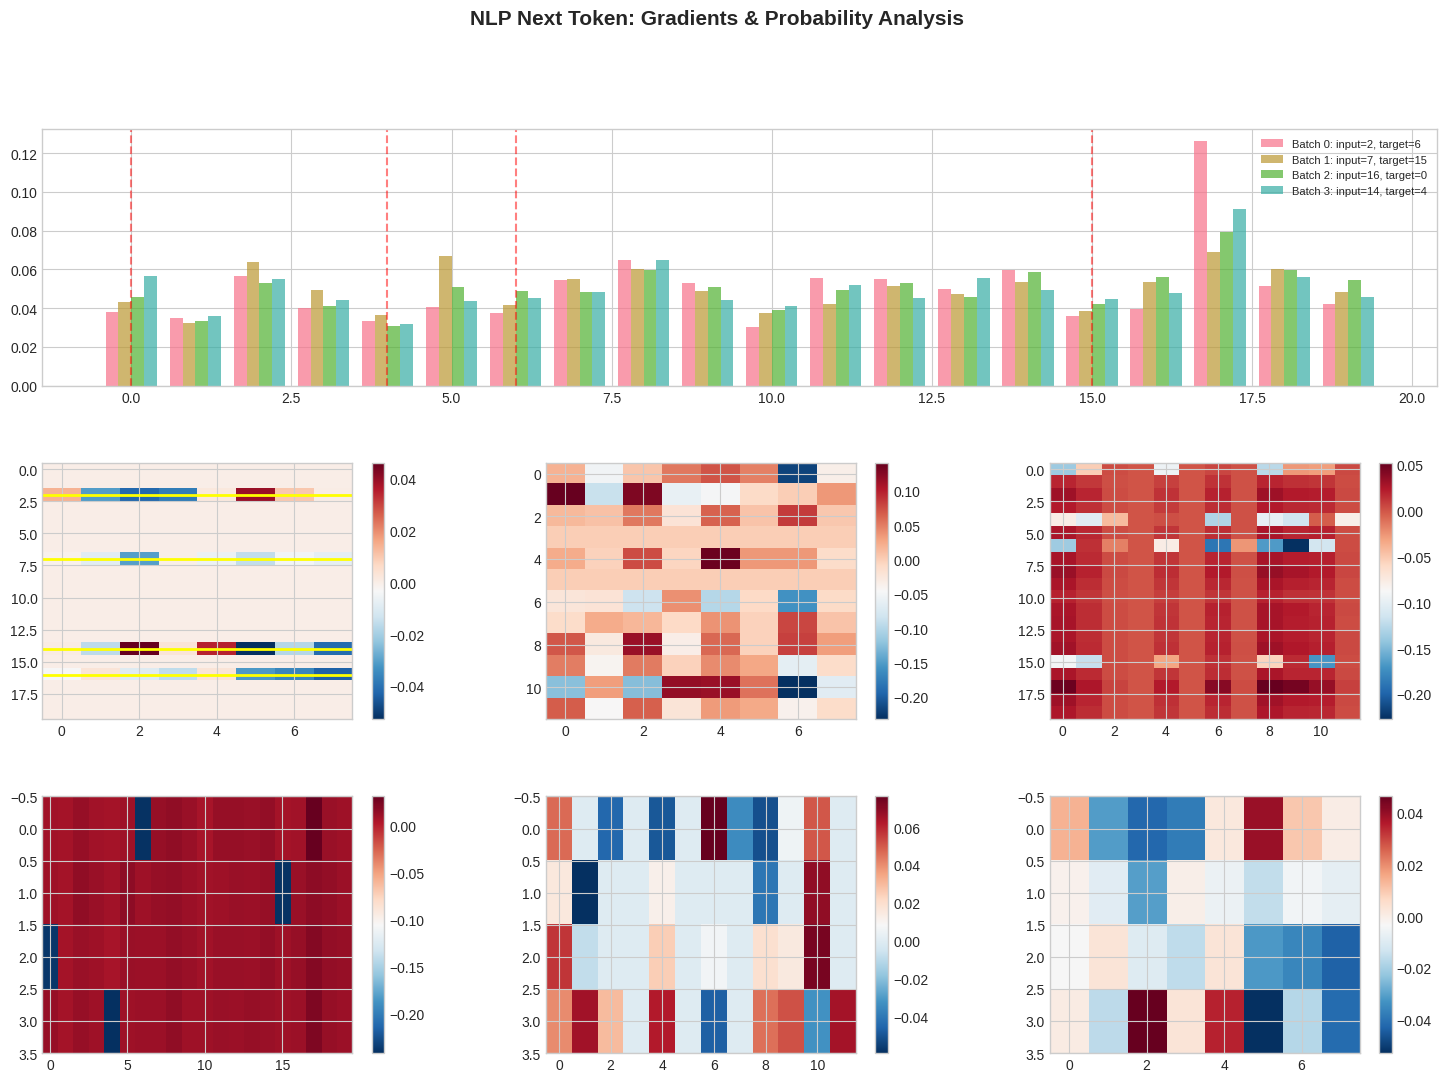

In [35]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('NLP Next Token: Gradients & Probability Analysis', fontsize=15, fontweight='bold')

# Probability Distribution
ax_probs = fig.add_subplot(gs[0, :])
probs = manual_grads_nlp['probs'].detach().numpy()
for i in range(BATCH_SIZE_NLP):
    ax_probs.bar(np.arange(VOCAB_SIZE) + i*0.2 - 0.3, probs[i], width=0.2, alpha=0.7,
                label=f'Batch {i}: input={x_tokens[i].item()}, target={y_next[i].item()}')
for y in y_next:
    ax_probs.axvline(x=y.item(), color='red', linestyle='--', alpha=0.5)
ax_probs.set_title('Softmax Probability Distribution', fontweight='bold')
ax_probs.legend(fontsize=8)

# Embedding Gradients (sparse!)
ax_embed = fig.add_subplot(gs[1, 0])
grad_E = manual_grads_nlp['embedding.weight'].detach().numpy()
im = ax_embed.imshow(grad_E, aspect='auto', cmap='RdBu_r')
ax_embed.set_title('Embedding Gradients (SPARSE)', fontweight='bold')
for token_idx in x_tokens:
    ax_embed.axhline(y=token_idx.item(), color='yellow', linewidth=2)
plt.colorbar(im, ax=ax_embed)

# FC1 & FC2 Gradients
ax_fc1 = fig.add_subplot(gs[1, 1])
im1 = ax_fc1.imshow(manual_grads_nlp['fc1.weight'].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax_fc1.set_title('FC1 Weight Gradients', fontweight='bold')
plt.colorbar(im1, ax=ax_fc1)

ax_fc2 = fig.add_subplot(gs[1, 2])
im2 = ax_fc2.imshow(manual_grads_nlp['fc2.weight'].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax_fc2.set_title('FC2 Weight Gradients', fontweight='bold')
plt.colorbar(im2, ax=ax_fc2)

# Error Signals
ax_dout = fig.add_subplot(gs[2, 0])
im3 = ax_dout.imshow(manual_grads_nlp['delta_output'].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax_dout.set_title('δ_output = softmax - y', fontweight='bold')
plt.colorbar(im3, ax=ax_dout)

ax_dhid = fig.add_subplot(gs[2, 1])
im4 = ax_dhid.imshow(manual_grads_nlp['delta_hidden'].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax_dhid.set_title('δ_hidden', fontweight='bold')
plt.colorbar(im4, ax=ax_dhid)

ax_demb = fig.add_subplot(gs[2, 2])
im5 = ax_demb.imshow(manual_grads_nlp['delta_embed'].detach().numpy(), aspect='auto', cmap='RdBu_r')
ax_demb.set_title('δ_embed', fontweight='bold')
plt.colorbar(im5, ax=ax_demb)

plt.savefig('nlp_grad_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Per Sample Chain Rule Breakdown

In [38]:

print("MATHEMATICAL DEEP DIVE: Per-Sample Chain Rule")


x_single = torch.randn(1, INPUT_DIM)
y_single = torch.tensor([[1.0]])

model_single = BinaryClassifierManual(INPUT_DIM, HIDDEN_DIM, 0.0)
model_single.eval()

out_single = model_single(x_single, store_cache=True)
loss_single = nn.BCELoss()(out_single, y_single)
manual_single = model_single.manual_backward(y_single, nn.BCELoss())

print(f"\nForward: ŷ = {out_single.item():.4f}, y = {y_single.item():.4f}")
print(f"Loss = {loss_single.item():.6f}")

print(f"\nSTEP 1: δ₂ = ŷ - y = {out_single.item():.4f} - {y_single.item():.4f} = {(out_single - y_single).item():.4f}")

print(f"\nSTEP 2: ReLU mask = {manual_single['relu_mask'].squeeze().detach().numpy()}")
print(f"        δ₁ = (W₂ᵀ·δ₂) ⊙ mask = {manual_single['delta1'].squeeze().detach().numpy().round(4)}")

print(f"\nSTEP 3: ∂L/∂W₂ = δ₂·a₁ᵀ = {manual_single['fc2.weight'].shape}")
print(f"        ∂L/∂W₁ = δ₁·xᵀ = {manual_single['fc1.weight'].shape}")

# Verify
model_single.zero_grad()
loss_single.backward()
for name in ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias']:
    diff = torch.abs(dict(model_single.named_parameters())[name].grad - manual_single[name]).max().item()
    print(f"\n{name}: manual vs PyTorch diff = {diff:.2e}")

MATHEMATICAL DEEP DIVE: Per-Sample Chain Rule

Forward: ŷ = 0.4669, y = 1.0000
Loss = 0.761666

STEP 1: δ₂ = ŷ - y = 0.4669 - 1.0000 = -0.5331

STEP 2: ReLU mask = [0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1.]
        δ₁ = (W₂ᵀ·δ₂) ⊙ mask = [-0.     -0.      0.      0.      0.1323  0.     -0.      0.     -0.0654
  0.     -0.0234  0.0931]

STEP 3: ∂L/∂W₂ = δ₂·a₁ᵀ = torch.Size([1, 12])
        ∂L/∂W₁ = δ₁·xᵀ = torch.Size([12, 10])

fc1.weight: manual vs PyTorch diff = 0.00e+00

fc1.bias: manual vs PyTorch diff = 0.00e+00

fc2.weight: manual vs PyTorch diff = 0.00e+00

fc2.bias: manual vs PyTorch diff = 0.00e+00


### Auto-Grad

In [39]:
print("=" * 70)
print("torch.autograd.grad vs .backward()")
print("=" * 70)

"""
## torch.autograd.grad vs .backward()

.backward(): Computes gradients, stores in .grad attributes.
    Use for: Standard training with optimizer.step()

autograd.grad(): Computes gradients, RETURNS them.
    Use for: Gradient penalties, meta-learning, analysis
    create_graph=True: Enables higher-order derivatives
    retain_graph=True: Keeps graph for multiple calls
"""

model_grad = BinaryClassifierManual(INPUT_DIM, HIDDEN_DIM, 0.0)
model_grad.eval()

x_test = torch.randn(3, INPUT_DIM)
y_test = torch.randint(0, 2, (3, 1)).float()

out_test = model_grad(x_test)
loss_test = nn.BCELoss()(out_test, y_test)

# Method 1: .backward()
model_grad.zero_grad()
loss_test.backward(retain_graph=True)
backward_grads = [p.grad.clone() for p in model_grad.parameters()]

# Method 2: autograd.grad()
autograd_grads = torch.autograd.grad(loss_test, list(model_grad.parameters()), retain_graph=True)

print("Comparison:")
for i, (bg, ag) in enumerate(zip(backward_grads, autograd_grads)):
    diff = torch.abs(bg - ag).max().item()
    print(f"  Param {i}: diff = {diff:.2e} {'Matched' if diff < 1e-5 else 'Not Matched'}")

# Higher-order derivatives
print("\n--- Higher-Order Derivatives ---")
x_higher = torch.randn(1, INPUT_DIM, requires_grad=True)
model_higher = BinaryClassifierManual(INPUT_DIM, HIDDEN_DIM, 0.0)
model_higher.eval()

out_h = model_higher(x_higher)
loss_h = nn.BCELoss()(out_h, torch.tensor([[1.0]]))

first_grad = torch.autograd.grad(loss_h, x_higher, create_graph=True)[0]
second_grad = torch.autograd.grad(first_grad.sum(), x_higher, retain_graph=True)[0]

print(f"First-order grad:  {first_grad[0, :3].detach().numpy().round(4)}")
print(f"Second-order grad: {second_grad[0, :3].detach().numpy().round(4)}")

torch.autograd.grad vs .backward()
Comparison:
  Param 0: diff = 0.00e+00 Matched
  Param 1: diff = 0.00e+00 Matched
  Param 2: diff = 0.00e+00 Matched
  Param 3: diff = 0.00e+00 Matched

--- Higher-Order Derivatives ---
First-order grad:  [-0.039   0.0634  0.0121]
Second-order grad: [-0.0059  0.0097  0.0018]


### Gradient Magnitude Comparison

# Gradient Magnitude

## What is Gradient Magnitude?

In neural networks, each parameter (weights and biases) has a gradient:

$$
\frac{\partial \mathcal{L}}{\partial \theta}
$$

The **gradient magnitude** is simply the size (strength) of this gradient vector, usually computed using the L2 norm:

```python
torch.norm(grad)

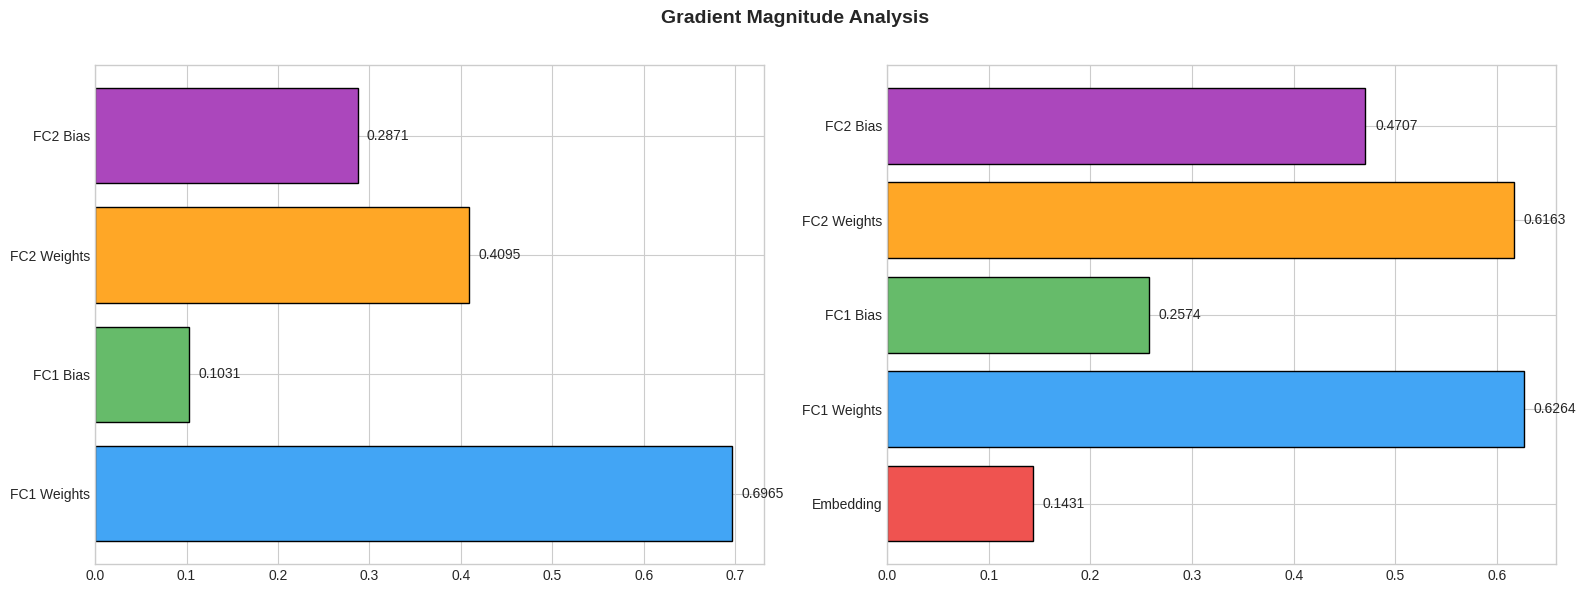

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gradient Magnitude Analysis', fontsize=14, fontweight='bold')

# Binary
binary_norms = {
    'FC1 Weights': torch.norm(manual_grads['fc1.weight']).item(),
    'FC1 Bias': torch.norm(manual_grads['fc1.bias']).item(),
    'FC2 Weights': torch.norm(manual_grads['fc2.weight']).item(),
    'FC2 Bias': torch.norm(manual_grads['fc2.bias']).item()
}
bars1 = axes[0].barh(list(binary_norms.keys()), list(binary_norms.values()),
                     color=['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC'], edgecolor='black')
axes[0].set_title('Binary Classification', fontweight='bold')
for bar, val in zip(bars1, binary_norms.values()):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

# NLP
nlp_norms = {
    'Embedding': torch.norm(manual_grads_nlp['embedding.weight']).item(),
    'FC1 Weights': torch.norm(manual_grads_nlp['fc1.weight']).item(),
    'FC1 Bias': torch.norm(manual_grads_nlp['fc1.bias']).item(),
    'FC2 Weights': torch.norm(manual_grads_nlp['fc2.weight']).item(),
    'FC2 Bias': torch.norm(manual_grads_nlp['fc2.bias']).item()
}
bars2 = axes[1].barh(list(nlp_norms.keys()), list(nlp_norms.values()),
                     color=['#EF5350', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC'], edgecolor='black')
axes[1].set_title('NLP Next Token', fontweight='bold')
for bar, val in zip(bars2, nlp_norms.values()):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('grad_magnitudes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()